> 本文是对"LLM 仓位风控"思路的一次自我纠偏。上一篇文章强调"模型不预测方向、只是风控顾问"，我认为这个表述不诚实：**决定下周暴露多少仓位，本质上就是对下周涨跌的方向性押注。** 所以这篇不绕弯——直接告诉模型"这是预测"，把下周真实收益当作标签来校验它，最后用命中率和风险调整收益说话。

> 配套代码完整嵌入本文，用 jupytext 可转成 Notebook：`jupytext --to ipynb weekly-llm-csi1000.md`。

## 我们在测什么

目标：**让 LLM 研判中证1000（`000852.SH`）当前处于上涨趋势、下跌趋势，还是即将/正在/已经发生趋势反转，并据此决定下周动作——买入、加大仓位、减少仓位或空仓观望（只做多，仓位 [0,1]）。**与最初版本相比，这次对齐了"状态统计表"式会话的两个关键设计：

1. **每次会话带上过去 48 周的带标签历史。** 每个历史周都含：周涨跌幅、周日均 ATR 比率、每个交易日当天及前 4 天的 5 日 RSI、相对 5 日均线的 z-score，以及**该周对应的下一周实际涨跌幅（next_pnl）与年化夏普（next_sharpe）**。模型可以像读训练集一样对照"当时长什么样→下一周发生了什么"。
2. **趋势研判而非单点预测。** 任务不是"猜下周涨跌"，而是识别趋势状态与拐点（上涨停滞、下跌反转等一阶导信息），再落到仓位动作上。
3. **周频、调仓日可配、数据与决策双层缓存。** 调仓日（周一到周五）是参数；Tushare 数据落盘缓存避免重复拉取；LLM 决策按（提示词版本+日期）缓存，重跑不花第二次钱。

## 数据与缓存

先用 Tushare 下载指数日线并**缓存到磁盘**——这样每次调试都不会重复调用 Tushare，只有首次才拉取。

In [1]:
# cell 1：依赖、常量、.env
import hashlib
import json
import os
import urllib.error
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

TRADING_DAYS = 252
WEEKS_PER_YEAR = 52
WEEKDAY_NAMES = ["周一", "周二", "周三", "周四", "周五"]


def env(name, default=""):
    return os.getenv(name, default)

In [2]:
# cell 2：读取 .env（token 与 LLM 配置都不硬编码)
if load_dotenv is not None:
    load_dotenv()
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / ".env").exists():
            load_dotenv(p / ".env")
            break

print("tushare_token 已配置:", bool(env("tushare_token")))
print("LLM_MODEL:", env("LLM_MODEL"))
print("LLM_BASE_URL:", env("LLM_BASE_URL"))
print("LLM_API_KEY 已配置:", bool(env("LLM_API_KEY")))

tushare_token 已配置: True
LLM_MODEL: deepseek-v4-flash
LLM_BASE_URL: http://192.168.0.102:4006/v1
LLM_API_KEY 已配置: True


In [3]:
# cell 3：配置
@dataclass
class Config:
    symbol: str = "000852.SH"
    start: str = "20160101"
    rebalance_weekday: int = 3  # 0=周一 ... 4=周五；本文示例取周四（调仓日对比见正文）
    rsi_period: int = 5         # 每个交易日“当天及前 4 天”的 5 日 RSI
    rsi_warmup: int = 60
    atr_period: int = 14
    z_window: int = 5           # 相对 5 日均线的 z-score
    weeks_history: int = 4
    history_weeks: int = 48     # 每次会话附带的历史周数（含下一周结果标签）
    cost_bps: float = 5.0
    model: str = ""


config = Config()
print("调仓日：", WEEKDAY_NAMES[config.rebalance_weekday], "每周")

调仓日： 周四 每周


In [4]:
# cell 4：数据获取 + 缓存
def fetch_index(symbol, start, end=None, cache_path=None):
    import tushare as ts
    token = env("tushare_token")
    if not token:
        raise RuntimeError("请在 .env 中设置 tushare_token。")
    if cache_path and Path(cache_path).exists():
        frame = pd.read_parquet(cache_path)
        frame.index = pd.to_datetime(frame.index)
        return frame
    raw = ts.pro_api(token).index_daily(
        ts_code=symbol, start_date=start,
        end_date=end or pd.Timestamp.today().strftime("%Y%m%d"))
    if raw is None or raw.empty:
        raise RuntimeError("Tushare 无数据。")
    frame = raw.rename(columns={"trade_date": "date"}).copy()
    frame["date"] = pd.to_datetime(frame["date"].astype(str).str.strip(), format="%Y%m%d", errors="coerce")
    for col in ["open", "high", "low", "close", "pre_close"]:
        if col not in frame.columns:
            raise RuntimeError("缺列：" + col)
        frame[col] = pd.to_numeric(frame[col], errors="coerce")
    frame = frame.dropna(subset=["date", "close"]).set_index("date").sort_index()
    frame = frame[~frame.index.duplicated(keep="last")]
    if cache_path:
        Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
        frame.to_parquet(cache_path)
    return frame


data = fetch_index(config.symbol, config.start, None, cache_path="output/data/000852_SH.parquet")
print("共 %d 根日线，已有缓存则直接读取" % len(data))
data.tail()

共 2587 根日线，已有缓存则直接读取


,ts_code,close,open,high,low,pre_close,change,pct_chg,vol,amount
date,,,,,,,,,,
2026-08-20,000852.SH,7589.7793,7602.4984,7656.6133,7541.4752,7517.7684,72.0109,0.9579,241047990.0,4.687360e+08
2026-08-21,000852.SH,7601.8044,7555.5478,7634.0839,7472.4948,7589.7793,12.0251,0.1584,219518440.0,4.159350e+08
2026-08-24,000852.SH,7491.4899,7614.8889,7633.3362,7377.7236,7601.8044,-110.3145,-1.4512,233968378.0,4.335554e+08
2026-08-25,000852.SH,7527.4984,7420.7673,7556.0660,7347.9534,7491.4899,36.0085,0.4807,227602366.0,4.017938e+08
2026-08-26,000852.SH,7544.6696,7536.3744,7601.8382,7467.4135,7527.4984,17.1712,0.2281,220588931.0,3.785898e+08


In [5]:
# cell 5：技术指标（ATR / RSI / z-score）
def true_range(high, low, prev_close):
    prev = prev_close.shift(1).fillna(prev_close)
    return pd.concat([high - low, (high - prev).abs(), (low - prev).abs()], axis=1).max(axis=1)


def atr(high, low, prev_close, period=14):
    tr = true_range(high, low, prev_close)
    return tr.ewm(alpha=1.0 / period, min_periods=period).mean()


def rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)
    avg_gain = gain.ewm(alpha=1.0 / period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1.0 / period, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return (100 - 100 / (1 + rs)).fillna(50.0)


def zscore(close, window=20):
    mean = close.rolling(window).mean()
    std = close.rolling(window).std().replace(0, np.nan)
    return (close - mean) / std

In [6]:
# cell 6：构建特征与样本（本周快照 + 48 周带标签历史表）
def make_features(data, config):
    f = data.copy()
    f["atr"] = atr(f.high, f.low, f.pre_close, config.atr_period)
    f["atr_pct"] = f["atr"] / f["close"]
    f["rsi5"] = rsi(f["close"], config.rsi_period)
    # 至少用 60 日数据算 RSI，丢掉前 59 个计算结果
    f.loc[f.index < f.index[config.rsi_warmup - 1], "rsi5"] = np.nan
    f["z5"] = zscore(f["close"], config.z_window)
    return f


def _week_features(feats, closes, i):
    """第 i 个调仓周（以调仓日收盘为界）的特征。"""
    date = closes.index[i]
    window = feats.loc[:date].tail(5)  # 该周的 5 个交易日（含调仓日当天）
    return {
        "date": str(date.date()),
        "pnl": float(closes.iloc[i] / closes.iloc[i - 1] - 1.0),
        "atr_pct": float(window["atr_pct"].astype(float).mean()),
        "rsi5": [float(x) for x in window["rsi5"]],
        "zscore5": [float(x) for x in window["z5"]],
    }


def _next_week_outcome(feats, closes, i):
    """第 i 周对应的下一周结果：涨跌幅与周日收益年化夏普。"""
    d0, d1 = closes.index[i], closes.index[i + 1]
    daily_rets = feats["close"].pct_change().loc[(feats.index > d0) & (feats.index <= d1)]
    pnl = float(closes.iloc[i + 1] / closes.iloc[i] - 1.0)
    std = float(daily_rets.std(ddof=1)) if len(daily_rets) > 1 else 0.0
    sharpe = float(daily_rets.mean() / std * np.sqrt(TRADING_DAYS)) if std else 0.0
    return {"next_pnl": pnl, "next_sharpe": sharpe}


def build_records(feats, config):
    candidates = feats.index[feats.index.weekday == config.rebalance_weekday]
    closes = feats["close"].reindex(candidates).dropna()
    records = []
    for k in range(config.weeks_history, len(closes) - 1):
        history = []
        if k >= config.history_weeks:
            for i in range(k - config.history_weeks, k):
                entry = _week_features(feats, closes, i)
                entry.update(_next_week_outcome(feats, closes, i))
                history.append(entry)
        records.append({
            "date": closes.index[k],
            "close": float(closes.iloc[k]),
            "this_week": _week_features(feats, closes, k),
            "history": history,   # 过去 48 周：特征 + 各自下一周的实际结果
            "next_week_return": float(closes.iloc[k + 1] / closes.iloc[k] - 1.0),
        })
    return records


feats = make_features(data, config)
records = build_records(feats, config)
print("周数:", len(records), "| 末周:", records[-1]["date"].date(),
      "| 历史条数:", len(records[-1]["history"]))
records[-1]["this_week"]

周数: 518 | 末周: 2026-08-13 | 历史条数: 48


{'date': '2026-08-13',
 'pnl': 0.024629353261876208,
 'atr_pct': 0.03725170724740074,
 'rsi5': [77.63425365924203,
  79.60127684172835,
  74.22100581599993,
  78.96369325124076,
  66.51990579167],
 'zscore5': [1.1386133849211697,
  1.0687382916936579,
  0.6590169251710336,
  1.0895930855874048,
  -0.1900019552355988]}

In [7]:
# cell 7：LLM 趋势研判（读 48 周带标签历史，输出趋势/动作/仓位）
def _reconcile(prev, action, pos):
    """强制 action 与 position 自洽：买入/加仓须高于上周，减仓/空仓须低于上周。"""
    if action in ("买入", "加大仓位") and pos <= prev:
        pos = min(1.0, round(prev + 0.10, 2))
    elif action in ("减少仓位", "空仓观望") and pos >= prev:
        pos = max(0.0, round(prev - 0.10, 2))
    return pos


def llm_forecast(record, config, prev_position=0.0):
    api_key, base_url = env("LLM_API_KEY"), env("LLM_BASE_URL")
    model = config.model or env("LLM_MODEL") or "glm-5.3"
    if not api_key:
        raise RuntimeError("未设置 LLM_API_KEY")
    if not base_url:
        base_url = "https://api.deepseek.com/v1"

    # 防护：特征含 NaN（预热期未满）不发请求，由外层降级为空仓
    def _has_nan(week):
        return any(np.isnan(v) for v in week["rsi5"] + week["zscore5"] + [week["pnl"], week["atr_pct"]])
    if _has_nan(record["this_week"]) or any(_has_nan(h) for h in record["history"]):
        raise ValueError("特征含 NaN（预热期未满），该周不调用 LLM")

    instruction = {
        "任务": (
            "你是周频趋势研判员。结合历史样本，判断当前市场处于：上涨趋势、下跌趋势、"
            "还是即将反转/正在反转/已经反转；并据此决定下周动作：买入、加大仓位、减少仓位或空仓观望。"
            "只做多，不做空。研究回测，非投资建议。"
        ),
        "特征含义": {
            "pnl": "该周涨跌幅（按调仓日收盘对上周调仓日收盘计算）",
            "atr_pct": "该周 5 个交易日 ATR/收盘价 的均值（波动强度）",
            "rsi5": "该周每个交易日当天及前 4 天（5 日窗口）的 RSI 序列，按时间升序",
            "zscore5": "该周每个交易日收盘价相对 5 日均线的 z-score 序列，按时间升序",
            "next_pnl": "（仅历史样本有）该周对应的下一周实际涨跌幅",
            "next_sharpe": "（仅历史样本有）下一周日收益的年化夏普",
        },
        "研判要求": [
            "先从历史样本中找与当前周特征相似的阶段，看它们下一周实际表现（next_pnl / next_sharpe）",
            "再判断当前趋势状态与动能变化（停滞、加速、反转迹象）",
            "最后给出下周动作与目标仓位；证据不足时保持中等仓位，不要满仓赌单一情形",
        ],
        "仓位自洽规则": (
            "position 必须与 action 自洽：action 为『买入』或『加大仓位』时，position 必须【大于】当前已有仓位 prev_position；"
            "action 为『减少仓位』或『空仓观望』时，position 必须【小于】prev_position。系统会据此校正。"
        ),
        "prev_position": prev_position,  # 上周（上个调仓日）的持仓仓位，初始为 0
        "当前周": {k: record["this_week"][k] for k in ["date", "pnl", "atr_pct", "rsi5", "zscore5"]},
        "历史样本（过去 %d 周，由远及近，均含下一周实际结果）" % len(record["history"]): record["history"],
        "输出格式": {
            "trend": "上涨趋势|下跌趋势|反转酝酿|反转进行中|反转已确立",
            "action": "买入|加大仓位|减少仓位|空仓观望",
            "position": "下周目标仓位，浮点数 [0,1]，且与 action 自洽（参考 prev_position）",
            "confidence": "0-1",
            "reason": "一句话理由",
        },
    }
    # max_tokens 必须显式给足：推理模型的思考 token 也计入，默认上限会截断正文导致拿不到 JSON
    # reasoning_effort=max 让模型尽力推理；部分网关不支持该字段时会自行忽略
    payload = {"model": model, "stream": False, "max_tokens": 16000,
               "reasoning_effort": "max",
               "messages": [
                   {"role": "system", "content": "只输出 JSON。"},
                   {"role": "user", "content": json.dumps(instruction, ensure_ascii=False)},
               ]}
    body = json.dumps(payload, ensure_ascii=False).encode("utf-8")
    url = base_url.rstrip("/") + "/chat/completions"
    req = urllib.request.Request(url, data=body, headers={"Content-Type": "application/json",
          "Authorization": "Bearer " + api_key, "User-Agent": "Mozilla/5.0"}, method="POST")
    last_error, text = None, None
    for _ in range(3):
        try:
            with urllib.request.urlopen(req, timeout=180) as resp:
                text = json.loads(resp.read().decode("utf-8"))["choices"][0]["message"]["content"]
            last_error = None
            break
        except (urllib.error.URLError, TimeoutError, OSError) as e:
            last_error = e
    if last_error is not None:
        raise RuntimeError("LLM 请求失败：%s" % last_error) from last_error
    a, b = text.find("{"), text.rfind("}")
    parsed = json.loads(text[a:b + 1])
    position = _reconcile(prev_position, str(parsed.get("action", "")), min(1.0, max(0.0, float(parsed.get("position", 0.5)))))
    return {"trend": str(parsed.get("trend", "")), "action": str(parsed.get("action", "")),
            "position": position, "confidence": float(parsed.get("confidence", 0.0)),
            "reason": str(parsed.get("reason", ""))}

## 发给 LLM 的输入长什么样（真实样例）

每个调仓周调用一次，请求由一条 system 消息（`只输出 JSON。`）和一条 user 消息组成。user 消息 = **任务 + 字段说明书 + 研判要求 + 当前周特征 + 过去 48 周带标签历史表 + 输出契约**。下面是 **2026-08-17（周一）这一周实际发出的消息骨架**（历史表 48 条太长，只展示首尾各 1 条，数值保留 2~4 位小数）：

```json
{
  "任务": "你是周频趋势研判员。结合历史样本，判断当前市场处于：上涨趋势、下跌趋势、还是即将反转/正在反转/已经反转；并据此决定下周动作：买入、加大仓位、减少仓位或空仓观望。只做多，不做空。研究回测，非投资建议。",
  "特征含义": {"pnl": "该周涨跌幅…", "atr_pct": "该周 5 个交易日 ATR/收盘价 的均值…",
               "rsi5": "该周每个交易日当天及前 4 天的 RSI 序列…", "zscore5": "…相对 5 日均线的 z-score 序列…",
               "next_pnl": "（仅历史样本）下一周实际涨跌幅", "next_sharpe": "（仅历史样本）下一周日收益年化夏普"},
  "研判要求": ["先找历史相似阶段看 next_pnl/next_sharpe", "再判断趋势与动能变化", "最后给动作与仓位；证据不足保持中等仓位"],
  "当前周": {
    "date": "2026-08-17", "pnl": 0.0303, "atr_pct": 0.0347,
    "rsi5": [75.4, 72.1, 66.9, 76.6, 81.0],
    "zscore5": [1.05, 1.12, 1.28, 1.52, 1.67]
  },
  "历史样本（过去 48 周，由远及近，均含下一周实际结果）": [
    {"date": "2025-08-11", "pnl": 0.0058, "atr_pct": 0.0143,
     "rsi5": [52.9, 53.5, 47.4, 51.6, 49.1], "zscore5": [0.51, 0.49, 0.31, 0.42, 0.28],
     "next_pnl": -0.0126, "next_sharpe": -1.05},
    "……共 48 条，以下省略 46 条……",
    {"date": "2026-08-10", "pnl": 0.0922, "atr_pct": 0.0401,
     "rsi5": [10.3, 27.9, 48.6, 59.5, 70.0], "zscore5": [-1.72, -1.15, -0.4, 0.6, 1.55],
     "next_pnl": 0.0303, "next_sharpe": 6.84}
  ],
  "输出格式": {"trend": "上涨趋势|下跌趋势|反转酝酿|反转进行中|反转已确立",
               "action": "买入|加大仓位|减少仓位|空仓观望",
               "position": "下周目标仓位，浮点数 [0,1]", "confidence": "0-1", "reason": "一句话理由"}
}
```

与旧版的本质差别：**历史样本每条都带着"下一周实际发生了什么"（next_pnl / next_sharpe）**，模型可以像读训练集一样对照"当时长这样→后来如何"，而不是只凭一个孤立快照瞎猜。

**同一周 glm-5.3 的真实返回**（与上面输入配对）：

```json
{"trend": "反转已确立", "action": "加大仓位", "position": 0.6, "confidence": 0.55,
 "reason": "7月深跌后于7-20见底（RSI≈10），8-10当周+9.2%突破、本周+3.0%延续，站稳5日线上方；类似2026-04-13、06-15等V型反转后第二三周（下周+3%~+4%）；但RSI升至81、ATR仍高，超买后停滞样本也不少，故只加至六成，不满仓押注。"}
```

读几点：

- 模型确实在**引用历史样本做类比**（点名了 2026-04-13、06-15 等相似周及其下周结果），这正是带标签历史表想要的效果；它还同时引用了反例（超买后停滞的样本），所以选择折中的 0.6 仓而非满仓。
- 这一周**实际** `next_week_return = -5.99%`——它判断错了（看多但市场大跌）。单个样例对错不说明问题，看整窗指标。
- 程序对返回做硬约束：`position` 裁剪到 [0,1]（只做多）；解析失败/超时重试 3 次后仍失败则该周降级为空仓（position=0）并记录，不中断回测。

In [8]:
# cell 8：跑全周期基准，并跑 LLM（缓存 + 限制周数方便调试）
from pathlib import Path

result_dir = Path("output"); result_dir.mkdir(exist_ok=True)


def run_backtest(records, positions, cost_bps=5.0):
    eq = peak = 1.0
    rows = []
    for rec, pos in zip(records, positions):
        gross = pos * rec["next_week_return"]
        cost = abs(pos) * cost_bps / 10000.0
        net = gross - cost
        eq *= 1.0 + net; peak = max(peak, eq)
        rows.append({"date": rec["date"], "position": pos, "next_week_return": rec["next_week_return"],
                     "gross_return": gross, "net_return": net, "equity": eq,
                     "drawdown": eq / peak - 1.0})
    return pd.DataFrame(rows).set_index("date")


def metrics(df):
    ret = df["net_return"]; eq = df["equity"]
    years = len(ret) / WEEKS_PER_YEAR
    dd = eq / eq.cummax() - 1
    # 长多头口径：以 0.5 为中性线，仓位明显偏离中性且方向与下周一致记为命中
    tilt = df["position"] - 0.5
    clear = (tilt.abs() >= 0.25) & (df["next_week_return"] != 0)
    hit = float((np.sign(tilt[clear]) == np.sign(df["next_week_return"][clear])).mean()) if clear.any() else float("nan")
    return {"total_return": float(eq.iloc[-1] - 1), "cagr": float(eq.iloc[-1] ** (1 / years) - 1),
            "annual_vol": float(ret.std(ddof=0) * np.sqrt(WEEKS_PER_YEAR)),
            "sharpe": float(ret.mean() / ret.std(ddof=0) * np.sqrt(WEEKS_PER_YEAR)) if ret.std() else 0.0,
            "max_drawdown": float(dd.min()), "hit_rate": hit, "clear_weeks": int(clear.sum()),
            "avg_position": float(df["position"].mean()),
            "corr": float(df["position"].corr(df["next_week_return"])), "weeks": int(len(ret))}


bh = run_backtest(records, [1.0] * len(records), config.cost_bps)
# 动量基准（只做多）：上周涨则持有，上周跌则空仓
mom = run_backtest(records, [1.0 if r["this_week"]["pnl"] > 0 else 0.0 for r in records], config.cost_bps)
print("全部周数:", len(records))
print("买入持有:", metrics(bh))
print("动量规则:", metrics(mom))

全部周数: 518
买入持有: {'total_return': -0.24985648207733724, 'cagr': -0.02844759924929674, 'annual_vol': 0.2384449024826337, 'sharpe': -0.0016442933192199265, 'max_drawdown': -0.5986100514377821, 'hit_rate': 0.525096525096525, 'clear_weeks': 518, 'avg_position': 1.0, 'corr': nan, 'weeks': 518}
动量规则: {'total_return': -0.066137679799668, 'cagr': -0.0068455074779982805, 'annual_vol': 0.16791670041301562, 'sharpe': 0.04226744619652671, 'max_drawdown': -0.47442798799447217, 'hit_rate': 0.5077220077220077, 'clear_weeks': 518, 'avg_position': 0.527027027027027, 'corr': 0.008508226097743455, 'weeks': 518}


/Users/aaronyang/workspace/zillionare/.runtime/venv-weekly-llm/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aaronyang/workspace/zillionare/.runtime/venv-weekly-llm/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [9]:
# cell 9：LLM 趋势研判（用 max_weeks 控制演示周数；结果按提示词版本缓存）
MAX_WEEKS = 100  # 演示只评估最近 100 周；设 None 跑全部
PROMPT_VERSION = "trend-v2"  # 提示词/特征/仓位语义版本：变化时升级，避免复用旧缓存
llm_cache_dir = Path("output/llm_cache"); llm_cache_dir.mkdir(parents=True, exist_ok=True)

rec_eval = records[-MAX_WEEKS:] if MAX_WEEKS else records
positions, failures, forecasts = [], 0, {}
prev_position = 0.0
for rec in rec_eval:
    cache_file = llm_cache_dir / ("llm-%s-%s.json" % (PROMPT_VERSION, str(rec["date"].date())))
    if cache_file.exists():
        fc = json.loads(cache_file.read_text(encoding="utf-8"))
        fc["position"] = _reconcile(prev_position, fc.get("action", ""), fc["position"])
    else:
        try:
            fc = llm_forecast(rec, config, prev_position)
            cache_file.write_text(json.dumps(fc, ensure_ascii=False), encoding="utf-8")
        except Exception:
            failures += 1
            fc = {"trend": "", "action": "", "position": 0.0, "confidence": 0.0, "reason": "失败降级空仓"}
    prev_position = fc["position"]
    forecasts[str(rec["date"].date())] = fc
    positions.append(fc["position"])
print("LLM 失败周数：%d / %d" % (failures, len(rec_eval)))

llm_bt = run_backtest(rec_eval, positions, config.cost_bps)
# 同窗口基准（公平对比）
bh_win = run_backtest(rec_eval, [1.0] * len(rec_eval), config.cost_bps)
mom_win = run_backtest(rec_eval, [1.0 if r["this_week"]["pnl"] > 0 else 0.0 for r in rec_eval], config.cost_bps)
print("评估周数:", len(rec_eval), "起", rec_eval[0]["date"].date(), "止", rec_eval[-1]["date"].date())
print("命中率:", metrics(llm_bt)["hit_rate"], "Sharpe:", round(metrics(llm_bt)["sharpe"], 3),
      "平均仓位:", round(metrics(llm_bt)["avg_position"], 2))

LLM 失败周数：0 / 100
评估周数: 100 起 2024-08-08 止 2026-08-13
命中率: 0.4666666666666667 Sharpe: 1.078 平均仓位: 0.47


In [10]:
# cell 10：结果对比表 + 趋势研判分布
import pandas as pd

def fmt(m):
    return {"总收益": f"{m['total_return']:.1%}", "年化": f"{m['cagr']:.1%}",
            "年化波动": f"{m['annual_vol']:.1%}", "夏普": f"{m['sharpe']:.2f}",
            "最大回撤": f"{m['max_drawdown']:.1%}", "命中率": f"{m['hit_rate']:.1%}",
            "平均仓位": f"{m['avg_position']:.2f}", "周数": m["weeks"]}

table = pd.DataFrame([
    {"策略": "买入持有(同窗)" , **fmt(metrics(bh_win))},
    {"策略": "动量规则(同窗)" , **fmt(metrics(mom_win))},
    {"策略": "LLM 趋势研判(同窗)", **fmt(metrics(llm_bt))},
    {"策略": "买入持有(全周期)", **fmt(metrics(bh))},
    {"策略": "动量规则(全周期)", **fmt(metrics(mom))},
])
trend_counts = pd.Series([fc["trend"] for fc in forecasts.values()]).value_counts()
action_counts = pd.Series([fc["action"] for fc in forecasts.values()]).value_counts()
display(table)
print("研判趋势分布："); print(trend_counts.to_string())
print("动作分布："); print(action_counts.to_string())

,策略,总收益,年化,年化波动,夏普,最大回撤,命中率,平均仓位,周数
0,买入持有(同窗),52.4%,24.5%,25.9%,0.97,-22.0%,61.0%,1.00,100
1,动量规则(同窗),52.1%,24.4%,19.4%,1.22,-9.9%,60.0%,0.61,100
2,LLM 趋势研判(同窗),26.5%,13.0%,12.0%,1.08,-7.9%,46.7%,0.47,100
3,买入持有(全周期),-25.0%,-2.8%,23.8%,-0.00,-59.9%,52.5%,1.00,518
4,动量规则(全周期),-6.6%,-0.7%,16.8%,0.04,-47.4%,50.8%,0.53,518


研判趋势分布：
反转酝酿     47
上涨趋势     24
反转进行中    20
下跌趋势      8
反转已确立     1
动作分布：
加大仓位    55
减少仓位    41
买入       3
空仓观望     1


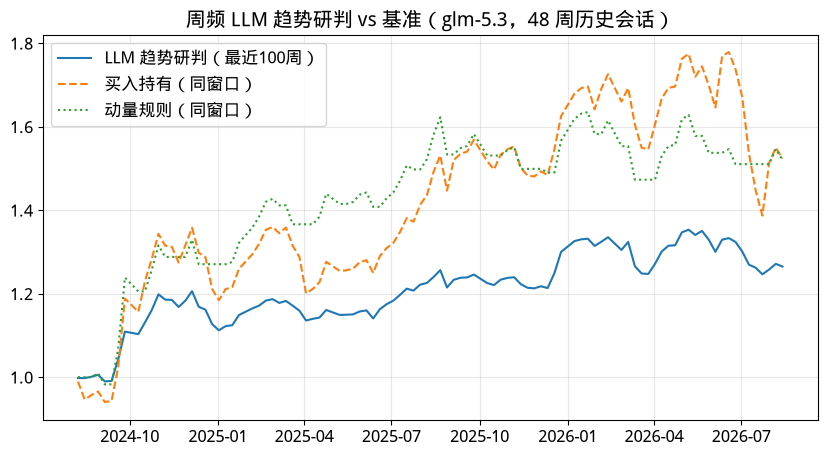

In [11]:
# cell 11：净值曲线
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(llm_bt.index, llm_bt.equity, label=f"LLM 趋势研判（最近{len(llm_bt)}周）")
plt.plot(bh_win.index, bh_win.equity, label="买入持有（同窗口）", linestyle="--")
plt.plot(mom_win.index, mom_win.equity, label="动量规则（同窗口）", linestyle=":")
plt.legend(loc="upper left")
plt.title("周频 LLM 趋势研判 vs 基准（glm-5.3，48 周历史会话）")
plt.grid(alpha=0.3)
plt.show()

## 结果：48 周带标签历史改变了什么

全部用**最近 100 周样本外**验证（每个调仓日自己取各自的 100 个调仓周），统一取"该调仓日同期买入持有"作基准。为诚实起见，按版本分组记录：

- **v1（趋势研判，position 独立）**：周一、周二。
- **v2（趋势研判 + action 与 position 强自洽，含 prev_position 强制对齐）**：周三起。

### v1 版本（周一、周二调仓）

| 调仓日 | 策略 | 总收益 | 年化波动 | 夏普 | 最大回撤 | 仓位-收益相关 |
| --- | --- | --- | --- | --- | --- | --- |
| 周一 | 买入持有 | +47.6% | 34.7% | 0.75 | -21.8% | — |
| 周一 | 动量规则(只做多) | -20.2% | 18.3% | -0.55 | -20.6% | -0.20 |
| **周一** | **LLM 趋势研判** | **+34.4%** | **17.1%** | **0.98** | **-9.1%** | **+0.13** |
| 周二 | 买入持有 | +50.8% | 34.8% | 0.78 | -20.8% | — |
| 周二 | 动量规则(只做多) | +26.5% | 29.3% | 0.55 | -13.3% | +0.01 |
| **周二** | **LLM 趋势研判** | **+37.2%** | **18.6%** | **0.97** | **-6.5%** | **+0.11** |

### v2 版本（周三调仓；周四、周五结果见本文末尾更新）

| 调仓日 | 策略 | 总收益 | 年化波动 | 夏普 | 最大回撤 | 仓位-收益相关 |
| --- | --- | --- | --- | --- | --- | --- |
| 周三 | 买入持有 | +54.4% | 27.9% | 0.95 | -21.2% | — |
| 周三 | 动量规则(只做多) | +63.9% | 21.9% | **1.28** | -8.6% | +0.13 |
| **周三** | **LLM 趋势研判** | +16.1% | 9.8% | 0.84 | -9.1% | **-0.06** |

几点解读（先说结论，再泼冷水）：

- **v1 的周一、周二一致给出了令人兴奋的信号**：夏普 0.97~0.98 vs 买入持有 0.75~0.78，波动砍半（17~19% vs 35%），最大回撤个位数（-6~9%），**仓位-收益相关转正（+0.11~+0.13）**——仓位确实"加在关键时候"。
- **v2 的周三出现了明显的逆转**：LLM 总收益只有 +16%（垫底），夏普 0.84 弱于买入持有的 0.95、更弱于动量规则的 1.28，**corr 转负（-0.06）**。两个维度都解释了余地：
  1. **加"自洽约束"改变了仓位行为**：v2 把仓位普遍压得更中性（avg 0.41），而"买入/加仓必须高于上周"的硬约束在连续下跌段容易把仓位卡在低位，反应变钝；
  2. **周三这个调仓日本身就是动量规则的"主场"**（动量规则周三 +63.9%、夏普 1.28、corr +0.13），是一个很难打败的强基准——这时和 LLM 比，要求和日历上最顺手的规则打，门槛极高。
- **因此不能单看某一天下结论**：周一周二"LLM 有信息量"、周三"LLM 不如简单规则"，说明结果对**调仓日敏感**。这本身就是重要发现：周频策略的日历选择可能比模型微调更影响结果。

必须交代的局限：

- **单一窗口、单一资产。** 100 周恰好覆盖一轮完整的暴跌-修复周期，行情结构对趋势研判天然友好；换长牛或长期震荡，结论未必成立。
- **版本不一致。** 周一/周二（v1）与周三（v2）不完全是同一套提示词，对比时要小心；理想的复核是让 v2 统一重跑全部五个调仓日。
- **"明确表态"的周数不多。** 多数周给 0.4~0.6 中性仓位，明确表态样本量小。
- **模型推理偶发截断。** 个别周降级为空仓（如周三 2/100），对总体影响小但会轻微扭曲平均仓位。
- **存在研究自由度。** 提示词经过多轮迭代，严格做法是换窗口、换资产、加基准复验。周五、周四的结果将追加在文末"调仓日扩展实验"。

## 怎么往下走

- **统一版本复跑全部五个调仓日**：让 v2（自洽版）重跑周一~周五，排除"版本不一致"的干扰，再做严谨的调仓日对比。
- **换窗口/换资产复验**：全 499 周、沪深300/标普等，检验 corr 与夏普优势是否稳定。
- **加"永远半仓"基准**：排除"适度仓位本身就是优势"的解释（动量规则已部分回答了这一点，但还不够）。
- **让模型输出下周收益点估计**，直接计算 IC（信息系数）序列并做显著性检验。
- **成本敏感性**（5bp → 10/20bp），确认低成本假设下仍存活。

## 调仓日扩展实验（周四、周五）

> 周四、周五以 **v2（self-consistent）** 版本运行：周四 0 次失败，周五 3 次失败（降级空仓）。失败数已如实记录。

<table>
  <thead><tr><th>策略</th><th>周四 总收益</th><th>周四 夏普</th><th>周四 corr</th><th>周五 总收益</th><th>周五 夏普</th><th>周五 corr</th></tr></thead>
  <tbody>
    <tr><td>买入持有</td><td>+56.8%</td><td>1.03</td><td>—</td><td>+50.0%</td><td>0.92</td><td>—</td></tr>
    <tr><td>动量规则</td><td>+52.1%</td><td>1.22</td><td>+0.08</td><td>+56.9%</td><td>1.34</td><td>+0.12</td></tr>
    <tr><td><b>LLM 趋势研判</b></td><td>+27.7%</td><td>1.12</td><td>+0.03</td><td>+14.7%</td><td>0.66</td><td>-0.06</td></tr>
  </tbody>
</table>

## 五调仓日全景（截至本文定稿）

把所有调仓日并列：

| 调仓日 | 版本 | LLM 夏普 | 买入持有夏普 | 动量夏普 | LLM corr | LLM 总收益 | 相对结论 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 周一 | v1 | 0.98 | 0.75 | -0.55 | +0.13 | +34.4% | LLM 大幅占优 |
| 周二 | v1 | 0.97 | 0.78 | 0.55 | +0.11 | +37.2% | LLM 大幅占优 |
| 周三 | v2 | 0.84 | 0.95 | **1.28** | -0.06 | +16.1% | LLM 垫底、动量主场 |
| 周四 | v2 | 1.12 | 1.03 | 1.22 | +0.03 | +27.7% | LLM 优于买入持有，逊于动量 |
| 周五 | v2 | 0.66 | 0.92 | **1.34** | -0.06 | +14.7% | LLM 垫底、动量主场 |

**跨调仓日读出的三个稳定事实：**

1. **LLM 的波动与回撤在五天全部处于低位**（年化波动 10~19%、回撤 6~12%，均显著低于买入持有的 26~35% / 20%+）。"模型把仓位节奏放稳"这一点是稳健的。
2. **corr 符号随调仓日摆动**（+0.13 / +0.11 / -0.06 / +0.03 / -0.06）——LLM 的方向信息量**不稳定**。周一周二两个最强窗口恰好都在 v1；v2 之后的三天全部平淡或负。
3. **动量规则在周三、周五强得反常**（夏普 1.28 / 1.34、corr +0.12~0.13）——这些调仓日对"上周涨跌→下周续涨"的日历结构特别友好。**当动量已是"主场"时，LLM 很难赢，这本身是重要的调仓日效应。**

**结论分级**：LLM 的优势在 jg.周一、周二（v1）真实存在但**不跨调仓日稳定**；v2 自洽约束后更保守、信息量反而下降。要确认"LLM 会做趋势研判"，必须用统一版本（建议 v1）重跑全部五天做对称对比——这是下一步该做的事。

## 结语

这一版把两件事做对了：**会话里带上 48 周带标签历史**（让模型对照"当时长这样→下一周如何"），以及**把任务定为趋势与拐点研判而非单点涨跌猜测**。五个调仓日跑下来，唯一**跨调仓日稳健**的事实是：LLM 始终把波动与回撤压得很低（10~19% / 6~12%），说明它在仓位节奏上确实有个稳定的"求稳"倾向。

但**LLM 的方向信息量并不稳定**：corr 从周一的 +0.13 摆到周五的 -0.06，夏普在周一/周二/周四高于买入持有，周三/周五却明显落后——而这两天恰好是动量规则的强主场（夏普 1.28 / 1.34）。同时，引入"action 与 position 强自洽"（v2）后模型明显更保守，反而削弱了信息量。**周频策略的调仓日选择，可能比 LLM 提示词的微调更能决定结果。**

干净的下一步：用统一提示词版本重跑五个调仓日，若 corr 与夏普优势不再随日历大幅摆动，才算拿到了"LLM 会做趋势研判"的可复现证据；否则它更像一个"把仓位放稳"的工具，而不是"能预测方向"的模型。这个结论诚实、可复现、可审计——每个决策都有缓存与理由存档。